In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Wed Mar  4 20:40:09 2026

@author: THE MAD TITAN
"""

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
import numpy as np
import logging

tf.get_logger().setLevel(logging.ERROR)

EPOCHS = 10
BATCH_SIZE = 128

# Load dataset.
mnist_dataset = keras.datasets.mnist
(train_images, train_labels), (test_images,
    test_labels) = mnist_dataset.load_data()


# padding images to 32x32.
train_images = np.pad(train_images, ((0, 0), (2, 2), (2, 2)), mode='constant')
test_images = np.pad(test_images, ((0, 0), (2, 2), (2, 2)), mode='constant')


# Standardize dataset.
mean = np.mean(train_images)
stddev = np.std(train_images)
train_images = (train_images - mean) / stddev
test_images = (test_images - mean) / stddev

print('mean: ', mean)
print('stddev: ', stddev)

# Change labels to one-hot.
train_labels = to_categorical(train_labels,
                              num_classes=10)
test_labels = to_categorical(test_labels,
                              num_classes=10)


mean:  25.50941642252604
stddev:  70.18042327879907


C:\Users\MUHAMMAD_KHURAM\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │       123,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,586 (533.54 KB)

 Trainable params: 136,586 (533.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 - 7s - 14ms/step - accuracy: 0.9306 - loss: 0.2196 - val_accuracy: 0.9748 - val_loss: 0.0833
Epoch 2/10
469/469 - 5s - 12ms/step - accuracy: 0.9791 - loss: 0.0651 - val_accuracy: 0.9823 - val_loss: 0.0529
Epoch 3/10
469/469 - 5s - 11ms/step - accuracy: 0.9852 - loss: 0.0450 - val_accuracy: 0.9836 - val_loss: 0.0480
Epoch 4/10
469/469 - 5s - 12ms/step - accuracy: 0.9894 - loss: 0.0335 - val_accuracy: 0.9855 - val_loss: 0.0446
Epoch 5/10
469/469 - 5s - 10ms/step - accuracy: 0.9913 - loss: 0.0267 - val_accuracy: 0.9864 - val_loss: 0.0398
Epoch 6/10
469/469 - 8s - 16ms/step - accuracy: 0.9929 - loss: 0.0212 - val_accuracy: 0.9880 - val_loss: 0.0389
Epoch 7/10
469/469 - 8s - 16ms/step - accuracy: 0.9938 - loss: 0.0187 - val_accuracy: 0.9851 - val_loss: 0.0480
Epoch 8/10
469/469 - 7s - 15ms/step - accuracy: 0.9941 - loss: 0.0164 - val_accuracy: 0.9887 - val_loss: 0.0371
Epoch 9/10
469/469 - 6s - 12ms/step - accuracy: 0.9958 - loss: 0.0123 - val_accuracy: 0.9857 - val_loss:

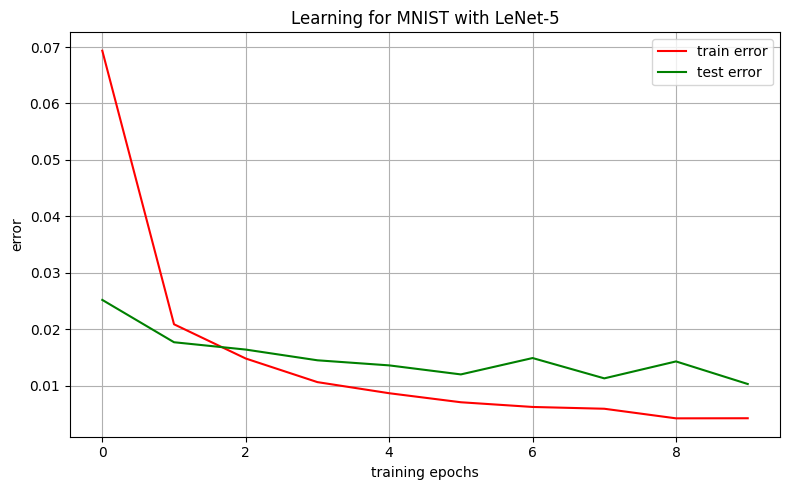

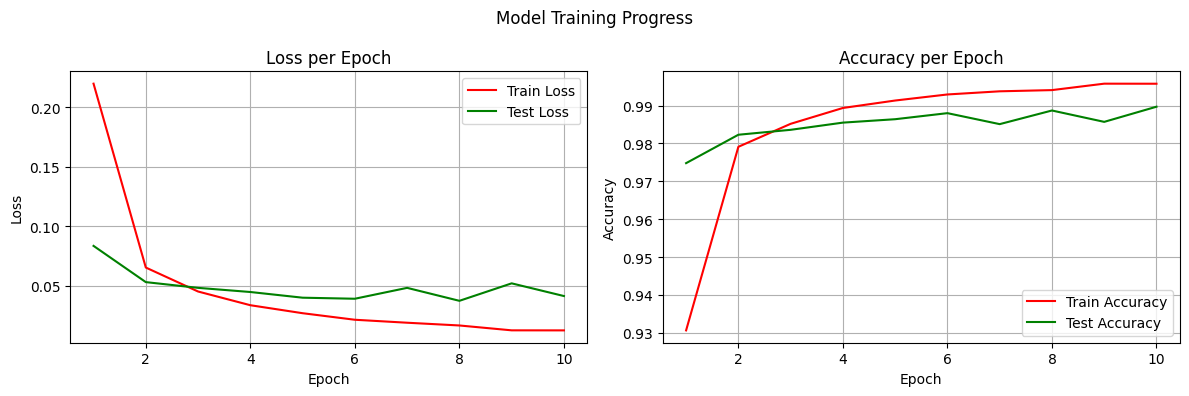

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


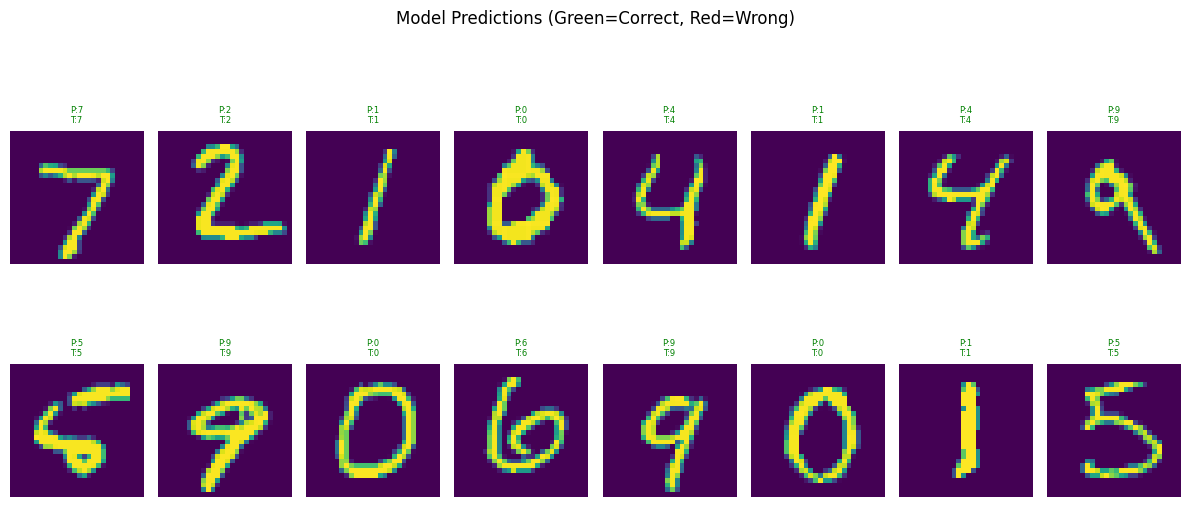

In [ ]:

# Build LeNet-5 model with 2 convolutional layers, 2 max-pooling layers, and 3 fully-connected layers.
model = Sequential()
model.add(Conv2D(6, (5, 5), strides=(1,1),
                activation='relu', padding='same',
                input_shape=(32, 32, 1),
                kernel_initializer='he_normal',
                bias_initializer='zeros'))

model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

model.add(Conv2D(16, (5, 5), strides=(1,1),
                activation='relu', padding='same',
                kernel_initializer='he_normal',
                bias_initializer='zeros'))

model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

model.add(Flatten()) # Flatten the 3D output to 1D for fully-connected layers because Dense layers expect 1D input.

model.add(Dense(120, activation='relu',
                kernel_initializer='he_normal',
                bias_initializer='zeros'))

model.add(Dense(84, activation='relu',
                kernel_initializer='he_normal',
                bias_initializer='zeros'))


model.add(Dense(10, activation='softmax',
                kernel_initializer='glorot_uniform',
                bias_initializer='zeros'))

model.compile(loss='categorical_crossentropy',
              optimizer='adam', metrics =['accuracy'])
model.summary()
history = model.fit(
    train_images, train_labels, validation_data =
    (test_images, test_labels), epochs=EPOCHS,
    batch_size=BATCH_SIZE, verbose=2, shuffle=True)



import matplotlib.pyplot as plt

# ============================================================
# 1. TRAINING HISTORY
# ============================================================
train_error = [1 - acc for acc in history.history['accuracy']]
test_error  = [1 - acc for acc in history.history['val_accuracy']]

plt.figure(figsize=(8, 5))
plt.plot(train_error, color='red',  label='train error')
plt.plot(test_error,  color='green', label='test error')
plt.xlabel('training epochs')
plt.ylabel('error')
plt.title('Learning for MNIST with LeNet-5')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 2. LIVE TRAINING LOSS & ACCURACY PER EPOCH
# ============================================================
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['loss'],     label='Train Loss', color='red')
plt.plot(epochs_range, history.history['val_loss'], label='Test Loss',  color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss per Epoch')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['accuracy'],     label='Train Accuracy', color='red')
plt.plot(epochs_range, history.history['val_accuracy'], label='Test Accuracy',  color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy per Epoch')
plt.legend()
plt.grid(True)

plt.suptitle('Model Training Progress')
plt.tight_layout()
plt.show()

# ============================================================
# 3. SAMPLE PREDICTIONS
# ============================================================
class_names = ['0','1','2','3','4','5','6','7','8','9']

# Get raw test images (before standardization) for display
mnist_dataset = tf.keras.datasets.mnist
(_, _), (raw_test_images, raw_test_labels) = mnist_dataset.load_data()

predictions = model.predict(test_images[:16])
pred_classes = np.argmax(predictions, axis=1)
true_classes = raw_test_labels[:16].flatten()

plt.figure(figsize=(12, 6))
for i in range(16):
    plt.subplot(2, 8, i+1)
    plt.imshow(raw_test_images[i])
    color = 'green' if pred_classes[i] == true_classes[i] else 'red'
    plt.title(f'P:{class_names[pred_classes[i]]}\nT:{class_names[true_classes[i]]}',
              fontsize=6, color=color)
    plt.axis('off')

plt.suptitle('Model Predictions (Green=Correct, Red=Wrong)')
plt.tight_layout()
plt.show()